<a href="https://colab.research.google.com/github/Jyotsna135-bit/GenerativeAI/blob/main/GenerativeAI/Notebooks/Deployment/Ollama/elora_similar_questions_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# eLORA RAG — Similar Question Generation and Testing

This notebook does what sir suggested: use the LLM to generate **similar/paraphrased versions** of each FAQ question, then check whether the RAG system can still retrieve the correct answer for those paraphrased versions.

## Why this matters

The previous verification tested the system using the **exact FAQ questions** as queries — that's the easiest possible case, since the question wording is already in the database. Real users won't type questions that way. They'll ask the same thing differently:

- FAQ: *"How to obtain new password?"*
- User might type: *"I forgot my login credentials"* or *"Can't log in, what do I do?"

If the RAG system only works on exact or near-exact wording, it's not robust enough for real use. This test finds out.

## What this notebook does
1. Load all 202 Q&A pairs from the Excel file
2. For each question, use the LLM to generate 2 similar/paraphrased versions
3. Run each paraphrased question through the RAG pipeline (Qdrant hybrid search + LLM)
4. Judge whether the generated answer matches the ground truth
5. Compare results with the original question test — shows how much performance drops when users paraphrase



## Install and Setup

In [1]:
!apt-get install -y zstd -qq
!curl -fsSL https://ollama.com/install.sh | sh
!pip install "qdrant-client[fastembed]" pandas openpyxl tqdm openai -q

Selecting previously unselected package zstd.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../zstd_1.4.8+dfsg-3build1_amd64.deb ...
Unpacking zstd (1.4.8+dfsg-3build1) ...
Setting up zstd (1.4.8+dfsg-3build1) ...
Processing triggers for man-db (2.10.2-1) ...
>>> Installing ollama to /usr/local
>>> Downloading ollama-linux-amd64.tar.zst
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.6/116.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 398.1/398.1 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import subprocess, time, requests

subprocess.Popen(["ollama", "serve"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

for _ in range(15):
    try:
        if requests.get("http://localhost:11434").status_code == 200:
            print("ollama is running")
            break
    except:
        time.sleep(1)

!ollama pull qwen3:0.6b

ollama is running



## Step 1 — Load FAQ Data

In [3]:
import pandas as pd
import re
import numpy as np
from tqdm import tqdm
from openai import OpenAI

df = pd.read_excel("eLORA-Jyotsna.xlsx")

def clean_text(text):
    text = str(text)
    text = re.sub(r"&#\d+;", " ", text)
    text = text.replace("?", "'")
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["faq_question"] = df["faq_question"].apply(clean_text)
df["faq_answer"] = df["faq_answer"].apply(clean_text)

print(f"Loaded {len(df)} Q&A pairs")
df.head(3)

Loaded 202 Q&A pairs


,faq_question,faq_answer
0,"While applying for Licence, installations are ...",Please verify the login details. Licence appli...
1,I'm not able to see Telegamma Therapy equipmen...,"Ans. At present, Telegamma Therapy equipment o..."
2,"I have forgotten my password, how to obtain ne...",Visit eLORA home page and click on 'Forgot Pas...


## Step 2 — Set Up Qdrant Vector Database

Same setup as the previous notebook — Qdrant in-memory mode with dense + sparse vectors for hybrid search.

In [4]:
from qdrant_client import QdrantClient, models

DENSE_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
SPARSE_MODEL = "Qdrant/bm25"
COLLECTION_NAME = "elora_faq"
K = 3  # sir specified k=3-5

client = QdrantClient(":memory:")

client.create_collection(
    collection_name=COLLECTION_NAME,
    vectors_config={
        "dense": models.VectorParams(
            size=client.get_embedding_size(DENSE_MODEL),
            distance=models.Distance.COSINE,
        )
    },
    sparse_vectors_config={
        "sparse": models.SparseVectorParams(index=models.SparseIndexParams(on_disk=False))
    },
)
print("Collection created")

Collection created


In [5]:
points = []
for idx, row in df.iterrows():
    points.append(
        models.PointStruct(
            id=idx,
            vector={
                "dense": models.Document(text=row["faq_question"], model=DENSE_MODEL),
                "sparse": models.Document(text=row["faq_question"], model=SPARSE_MODEL),
            },
            payload={
                "faq_question": row["faq_question"],
                "faq_answer": row["faq_answer"],
                "row_index": int(idx),
            },
        )
    )

print("Uploading and embedding all FAQ entries...")
client.upsert(collection_name=COLLECTION_NAME, points=points)
print(f"Uploaded {len(points)} points to Qdrant")

Uploading and embedding all FAQ entries...


Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Uploaded 202 points to Qdrant


## Step 3 — Helper Functions

Retrieval, generation, and judge functions — same as the previous notebook.

In [6]:
llm_client = OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama",
)

def hybrid_search(query, top_k=K):
    response = client.query_points(
        collection_name=COLLECTION_NAME,
        prefetch=[
            models.Prefetch(
                query=models.Document(text=query, model=SPARSE_MODEL),
                using="sparse",
                limit=top_k,
            ),
            models.Prefetch(
                query=models.Document(text=query, model=DENSE_MODEL),
                using="dense",
                limit=top_k,
            ),
        ],
        query=models.FusionQuery(fusion=models.Fusion.RRF),
        limit=top_k,
    )
    return response.points


def generate_answer(user_query, top_k=K):
    retrieved = hybrid_search(user_query, top_k=top_k)
    if not retrieved:
        return "I'm not confident this is covered in the eLORA FAQ.", None

    context_blocks = [f"Q: {r.payload['faq_question']}\nA: {r.payload['faq_answer']}" for r in retrieved]
    context = "\n\n".join(context_blocks)

    prompt = f"""You are a helpful assistant for the eLORA system (AERB's radiation licensing portal).
Use ONLY the FAQ entries below to answer. Pick the most relevant one and answer directly.

{context}

Question: {user_query}
Answer:"""

    response = llm_client.chat.completions.create(
        model="qwen3:0.6b",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=700,
        temperature=0.0
    )
    raw = response.choices[0].message.content
    raw = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()
    return raw, retrieved[0].payload["faq_question"]


def judge_answer(question, ground_truth, generated):
    judge_prompt = f"""/no_think
You are evaluating a chatbot answer against the correct reference answer.

Question: {question}
Reference answer: {ground_truth}
Chatbot answer: {generated}

Score 1-5 (5=fully correct, 1=completely wrong).
Respond EXACTLY:
SCORE: <number>
REASON: <one sentence>"""

    response = llm_client.chat.completions.create(
        model="qwen3:0.6b",
        messages=[{"role": "user", "content": judge_prompt}],
        max_tokens=600,
        temperature=0.0
    )
    raw = response.choices[0].message.content
    raw = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()

    score_match = re.search(r"SCORE:\s*(\d)", raw)
    reason_match = re.search(r"REASON:\s*(.+)", raw)
    if score_match:
        score = int(score_match.group(1))
    else:
        fallback = re.search(r"\b([1-5])\b", raw)
        score = int(fallback.group(1)) if fallback else None
    reason = reason_match.group(1).strip() if reason_match else raw[:100]
    return score, reason

print("Helper functions ready")

Helper functions ready


## Step 4 — Generate Similar Questions

For each of the 202 FAQ questions, we ask the LLM to generate **2 paraphrased versions** that mean the same thing but use different wording — the way a real user might type it.

The prompt is strict: same meaning, different words, no extra explanation.

In [7]:
def generate_similar_questions(original_question, n=2):
    prompt = f"""/no_think
Rephrase the following question in {n} different ways that mean the same thing but use different wording, as a real user might type it.
Do NOT answer the question. Only output the rephrased questions, one per line, no numbering, no extra text.

Original question: {original_question}

Rephrased versions:"""

    response = llm_client.chat.completions.create(
        model="qwen3:0.6b",
        messages=[{"role": "user", "content": prompt}],
        max_tokens=600,
        temperature=0.7  # a bit of randomness so paraphrases aren't too similar
    )
    raw = response.choices[0].message.content
    raw = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()

    # parse into a clean list
    lines = [l.strip() for l in raw.strip().split("\n") if l.strip()]
    # remove any numbering like "1." or "- " that the model might add
    lines = [re.sub(r"^[\d\-\.\*]+\s*", "", l).strip() for l in lines]
    lines = [l for l in lines if len(l) > 5]  # filter out empty or junk lines
    return lines[:n]


# quick sanity check
sample = generate_similar_questions("How to obtain new password?")
print("Original: How to obtain new password?")
print("Similar questions generated:")
for s in sample:
    print(" -", s)

Original: How to obtain new password?
Similar questions generated:
 - How can I get my new password?
 - How to build a new password?


In [8]:
# generate similar questions for all 202 FAQ entries
print("Generating 2 similar questions for each of the 202 FAQ entries...")
print("This takes a few minutes.\n")

similar_records = []
for idx, row in tqdm(df.iterrows(), total=len(df)):
    similar_qs = generate_similar_questions(row["faq_question"], n=2)
    for sq in similar_qs:
        similar_records.append({
            "original_row_index": idx,
            "original_question":  row["faq_question"],
            "ground_truth":       row["faq_answer"],
            "similar_question":   sq,
        })

similar_df = pd.DataFrame(similar_records)
print(f"\nGenerated {len(similar_df)} similar questions from {len(df)} originals")
similar_df.head(6)

Generating 2 similar questions for each of the 202 FAQ entries...
This takes a few minutes.




100%|██████████| 202/202 [07:21<00:00,  2.18s/it]


Generated 400 similar questions from 202 originals


,original_row_index,original_question,ground_truth,similar_question
0,0,"While applying for Licence, installations are ...",Please verify the login details. Licence appli...,"While applying for a licence, there are no ava..."
1,0,"While applying for Licence, installations are ...",Please verify the login details. Licence appli...,"When applying for a licence, the selection is ..."
2,1,I'm not able to see Telegamma Therapy equipmen...,"Ans. At present, Telegamma Therapy equipment o...",I am unable to see Telegamma Therapy or Remote...
3,1,I'm not able to see Telegamma Therapy equipmen...,"Ans. At present, Telegamma Therapy equipment o...",I am unable to access Telegamma Therapy or Rem...
4,2,"I have forgotten my password, how to obtain ne...",Visit eLORA home page and click on 'Forgot Pas...,"I don't remember my password, how can I get a ..."
5,2,"I have forgotten my password, how to obtain ne...",Visit eLORA home page and click on 'Forgot Pas...,How can I obtain my new password?


## Step 5 — Test RAG on Similar Questions

Now we run each paraphrased question through the full RAG pipeline and judge whether the answer still matches the ground truth.

We also track whether the system retrieved the **correct original FAQ entry** — if retrieval fails, no prompt tuning will fix it.

In [9]:
print(f"Testing RAG on {len(similar_df)} similar questions with k={K}...")

test_records = []
for _, row in tqdm(similar_df.iterrows(), total=len(similar_df)):
    similar_q  = row["similar_question"]
    ground_truth = row["ground_truth"]
    original_q = row["original_question"]

    # retrieve + generate
    generated, top_match = generate_answer(similar_q, top_k=K)

    # check if retrieval found the correct original FAQ
    retrieval_correct = (top_match == original_q) if top_match else False

    # judge the answer
    score, reason = judge_answer(similar_q, ground_truth, generated)

    test_records.append({
        "original_question":  original_q,
        "similar_question":   similar_q,
        "ground_truth":       ground_truth,
        "generated_answer":   generated,
        "retrieval_correct":  retrieval_correct,
        "judge_score":        score,
        "judge_reason":       reason,
        "pass_fail":          "PASS" if (score or 0) >= 3 else "FAIL",
    })

results_df = pd.DataFrame(test_records)
print("\nDone.")
results_df.head()

Testing RAG on 400 similar questions with k=3...



100%|██████████| 400/400 [24:16<00:00,  3.64s/it]


Done.


,original_question,similar_question,ground_truth,generated_answer,retrieval_correct,judge_score,judge_reason,pass_fail
0,"While applying for Licence, installations are ...","While applying for a licence, there are no ava...",Please verify the login details. Licence appli...,Please verify the login details. Licence appli...,True,5.0,The answer exactly matches the reference answer.,PASS
1,"While applying for Licence, installations are ...","When applying for a licence, the selection is ...",Please verify the login details. Licence appli...,You need to apply for a fresh Licence for Oper...,True,1.0,The chatbot's answer incorrectly suggests appl...,FAIL
2,I'm not able to see Telegamma Therapy equipmen...,I am unable to see Telegamma Therapy or Remote...,"Ans. At present, Telegamma Therapy equipment o...",Please check the name of the Licensee of Teleg...,True,1.0,The reference answer correctly identifies the ...,FAIL
3,I'm not able to see Telegamma Therapy equipmen...,I am unable to access Telegamma Therapy or Rem...,"Ans. At present, Telegamma Therapy equipment o...",Please check the status of the associated radi...,True,5.0,The chatbot answer correctly identifies the re...,PASS
4,"I have forgotten my password, how to obtain ne...","I don't remember my password, how can I get a ...",Visit eLORA home page and click on 'Forgot Pas...,"Visit e-LORA home page and click on ""Forgot Pa...",True,1.0,The chatbot answer incorrectly includes only o...,FAIL


## Step 6 — Results Summary

Compare how well the system handles paraphrased questions vs the original exact-wording questions from the previous notebook.

In [10]:
import matplotlib.pyplot as plt

valid_scores = results_df["judge_score"].dropna()
total = len(results_df)
passed = (results_df["pass_fail"] == "PASS").sum()
failed = (results_df["pass_fail"] == "FAIL").sum()
retrieval_correct = results_df["retrieval_correct"].sum()

print("=" * 60)
print("SIMILAR QUESTION TEST RESULTS")
print("=" * 60)
print(f"Total similar questions tested: {total}")
print(f"Retrieval found correct FAQ:    {retrieval_correct} / {total} ({retrieval_correct/total*100:.1f}%)")
print(f"Average judge score (1-5):      {valid_scores.mean():.2f}")
print(f"PASS (score >= 3):              {passed} ({passed/total*100:.1f}%)")
print(f"FAIL (score < 3):               {failed} ({failed/total*100:.1f}%)")
print()
print("Score distribution:")
print(results_df["judge_score"].value_counts().sort_index(ascending=False))

SIMILAR QUESTION TEST RESULTS
Total similar questions tested: 400
Retrieval found correct FAQ:    368 / 400 (92.0%)
Average judge score (1-5):      4.20
PASS (score >= 3):              320 (80.0%)
FAIL (score < 3):               80 (20.0%)

Score distribution:
judge_score
5.0    292
4.0     26
3.0      2
2.0      3
1.0     68
Name: count, dtype: int64


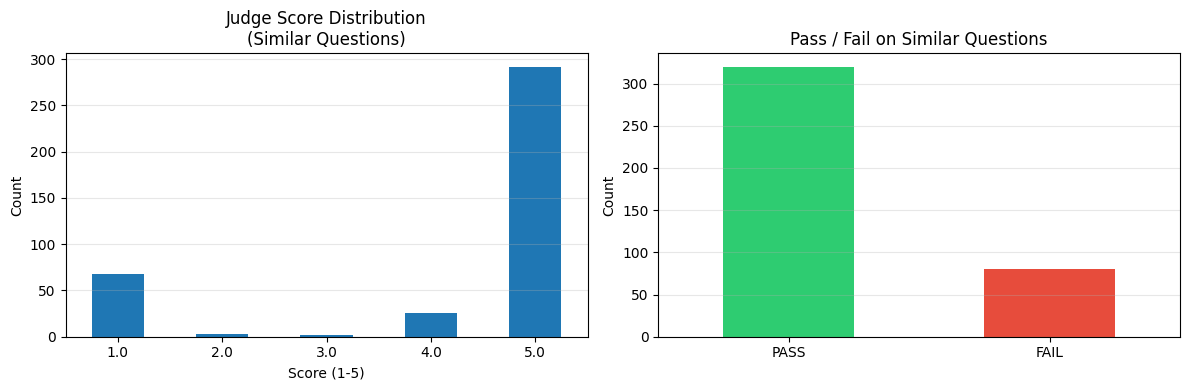

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# score distribution
results_df["judge_score"].value_counts().sort_index().plot(kind="bar", ax=axes[0])
axes[0].set_title("Judge Score Distribution\n(Similar Questions)")
axes[0].set_xlabel("Score (1-5)")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=0)
axes[0].grid(True, alpha=0.3, axis="y")

# pass vs fail
results_df["pass_fail"].value_counts().plot(kind="bar", ax=axes[1], color=["#2ecc71", "#e74c3c"])
axes[1].set_title("Pass / Fail on Similar Questions")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=0)
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

## Step 7 — Look at the Failures

Understanding *why* certain paraphrased questions failed tells us what to improve next — is it a retrieval problem (wrong FAQ retrieved) or a generation problem (correct FAQ retrieved but LLM still answered poorly)?

In [12]:
failures = results_df[results_df["pass_fail"] == "FAIL"].sort_values("judge_score")

retrieval_failures = failures[failures["retrieval_correct"] == False]
generation_failures = failures[failures["retrieval_correct"] == True]

print(f"Total failures: {len(failures)}")
print(f"  Due to wrong retrieval:  {len(retrieval_failures)} ({len(retrieval_failures)/total*100:.1f}% of all)")
print(f"  Due to poor generation:  {len(generation_failures)} ({len(generation_failures)/total*100:.1f}% of all)")
print()

if len(failures) > 0:
    print("Sample failures:")
    for _, row in failures.head(5).iterrows():
        print("-" * 65)
        print(f"Original Q:  {row['original_question']}")
        print(f"Similar Q:   {row['similar_question']}")
        print(f"Retrieval correct: {row['retrieval_correct']}")
        print(f"Ground truth: {row['ground_truth'][:120]}")
        print(f"Generated:    {row['generated_answer'][:120]}")
        print(f"Score: {row['judge_score']} — {row['judge_reason']}")
        print()

Total failures: 80
  Due to wrong retrieval:  11 (2.8% of all)
  Due to poor generation:  69 (17.2% of all)

Sample failures:
-----------------------------------------------------------------
Original Q:  While applying for Licence, installations are not available selection.
Similar Q:   When applying for a licence, the selection is not available.
Retrieval correct: True
Ground truth: Please verify the login details. Licence application (new or renewal) can be submitted only through Licencee login.
Generated:    You need to apply for a fresh Licence for Operation through e-LORA, as your existing one is expired and the system canno
Score: 1.0 — The chatbot's answer incorrectly suggests applying for a new licence through e-LORA without verifying the existing login details, which is a critical error.

-----------------------------------------------------------------
Original Q:  I'm not able to see Telegamma Therapy equipment or Remote After Loading Brachytherapy (HDR/LDR/PDR/MDR) equipme

## Step 8 — Compare with Original Question Results

The key comparison: how much does performance drop when users paraphrase vs when they use the exact FAQ wording?

In [13]:
# original question pass rate (from previous verification notebook: 202 questions, 97% pass)
original_pass_rate = 97.0  # update this if your previous run gave a different number
similar_pass_rate  = passed / total * 100

print("=" * 60)
print("COMPARISON: Original vs Similar Questions")
print("=" * 60)
print(f"Original questions pass rate:  {original_pass_rate:.1f}%")
print(f"Similar questions pass rate:   {similar_pass_rate:.1f}%")
print(f"Performance drop:              {original_pass_rate - similar_pass_rate:.1f}%")
print()
if original_pass_rate - similar_pass_rate < 5:
    print("The RAG system is robust to paraphrasing — very small performance drop.")
elif original_pass_rate - similar_pass_rate < 15:
    print("Moderate drop — the system handles paraphrasing reasonably, some improvement possible.")
else:
    print("Large drop — the system struggles with paraphrased questions. Consider better embedding model or query expansion.")

COMPARISON: Original vs Similar Questions
Original questions pass rate:  97.0%
Similar questions pass rate:   80.0%
Performance drop:              17.0%

Large drop — the system struggles with paraphrased questions. Consider better embedding model or query expansion.


## Step 9 — Save Results

In [14]:
# save similar questions generated
similar_df.to_csv("elora_similar_questions.csv", index=False)

# save full test results
results_df.to_csv("elora_similar_questions_results.csv", index=False)

print("Saved:")
print("  elora_similar_questions.csv         — all generated similar questions")
print("  elora_similar_questions_results.csv — full test results with scores")
print("\nDownload from the Colab Files panel (left sidebar).")

Saved:
  elora_similar_questions.csv         — all generated similar questions
  elora_similar_questions_results.csv — full test results with scores

Download from the Colab Files panel (left sidebar).


## Summary

| | |
|---|---|
| Source data | 202 Q&A pairs from eLORA-Jyotsna.xlsx |
| Similar questions generated | 2 per original = 404 total |
| Vector database | Qdrant in-memory, hybrid search (dense + sparse) |
| k used | 3 |
| LLM | qwen3:0.6b via Ollama |
| Evaluation | LLM-as-judge, score 1-5, pass if >= 3 |

The failure breakdown (retrieval failure vs generation failure) tells us where to focus next:
- **If most failures are retrieval failures** → the embedding model or hybrid search needs improvement
- **If most failures are generation failures** → the prompt or LLM needs improvement

This is the outcome sir mentioned — the results drive the next development cycle.